In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
import seaborn as sns


# 1. Cargar los datos

In [2]:

data = pd.read_csv("datos3_snubber_data_formatted.txt", sep="\t")
print(data.head())



   Hours  Status Group
0     90       1   Old
1     90       1   Old
2     90       0   Old
3    190       0   Old
4    218       0   Old


# 2. Separar los grupos

In [3]:

data_old = data[data['Group'] == "Old"]
data_new = data[data['Group'] == "New"]



# 3. Crear y ajustar modelos Kaplan-Meier para cada grupo por separado

In [4]:

kmf_old = KaplanMeierFitter()
kmf_new = KaplanMeierFitter()

kmf_old.fit(data_old['Hours'], event_observed=data_old['Status'], label='Old')
kmf_new.fit(data_new['Hours'], event_observed=data_new['Status'], label='New')



<lifelines.KaplanMeierFitter:"New", fitted with 54 total observations, 36 right-censored observations>

# 4. Graficar las curvas juntas

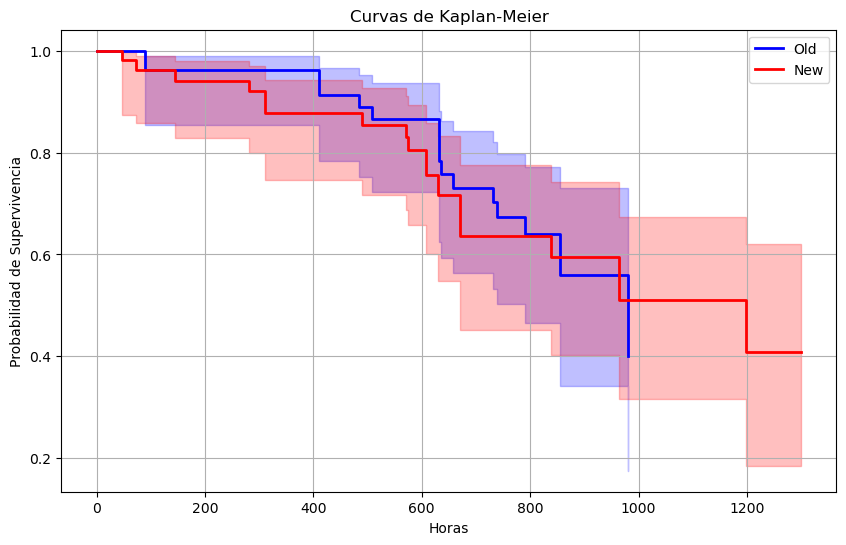

In [5]:

plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

kmf_old.plot(ax=ax, color='blue', linewidth=2)
kmf_new.plot(ax=ax, color='red', linewidth=2)

plt.title('Curvas de Kaplan-Meier')
plt.xlabel('Horas')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(True)
plt.show()



# 5. Ajustar modelo combinado y graficar con mejor presentación

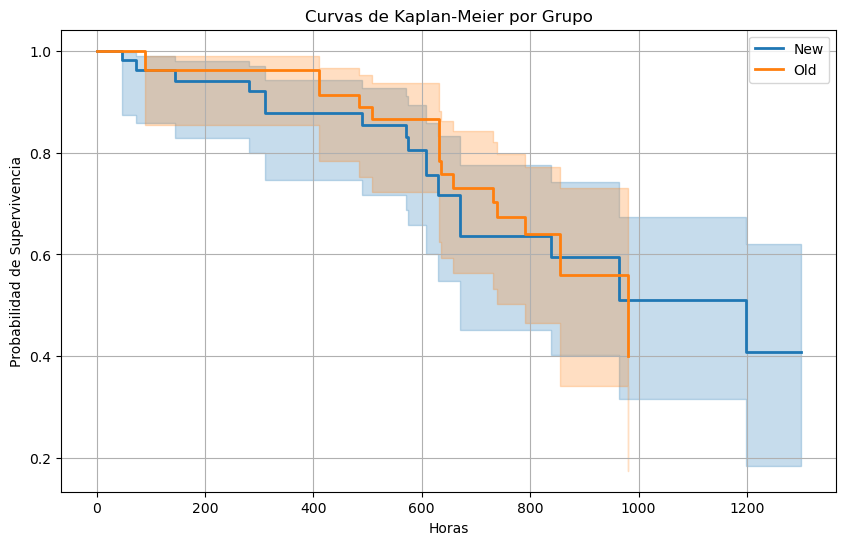

In [5]:

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

for name, grouped_df in data.groupby('Group'):
    kmf.fit(grouped_df['Hours'], event_observed=grouped_df['Status'], label=name)
    kmf.plot(ax=ax, linewidth=2)

plt.title('Curvas de Kaplan-Meier por Grupo')
plt.xlabel('Horas')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(True)
plt.show()



# 6. Realizar el Log-Rank Test

In [6]:

results = logrank_test(data_old['Hours'], data_new['Hours'],
                       event_observed_A=data_old['Status'],
                       event_observed_B=data_new['Status'])



In [7]:
results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.02 0.88      0.19

# 7. Mostrar resultados

In [8]:

print("\nResultados del Log-Rank Test:")
print(f"Estadístico de prueba: {results.test_statistic:.4f}")
print(f"Valor p: {results.p_value:.4f}\n")

# Interpretación
if results.p_value < 0.05:
    print("Conclusión: Existe diferencia significativa entre los grupos (p < 0.05)")
    print("Los grupos NO son iguales en términos de supervivencia.")
else:
    print("Conclusión: No hay diferencia significativa entre los grupos (p ≥ 0.05)")
    print("No podemos rechazar la hipótesis de que los grupos son iguales.")



Resultados del Log-Rank Test:
Estadístico de prueba: 0.0234
Valor p: 0.8785

Conclusión: No hay diferencia significativa entre los grupos (p ≥ 0.05)
No podemos rechazar la hipótesis de que los grupos son iguales.


# 8. Gráfico profesional con intervalos de confianza y valor p

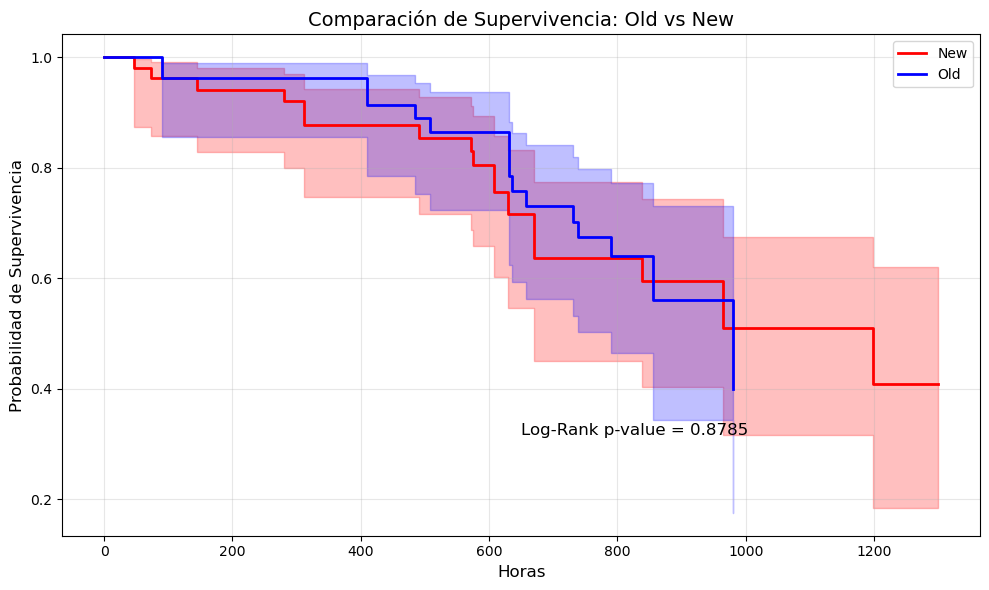

In [9]:


plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# Configurar colores
palette = {'Old': 'blue', 'New': 'red'}

for name, grouped_df in data.groupby('Group'):
    kmf.fit(grouped_df['Hours'], event_observed=grouped_df['Status'], label=name)
    kmf.plot(ax=ax, ci_show=True, color=palette[name], linewidth=2)

# Añadir el valor p manualmente
plt.text(0.5, 0.2, f'Log-Rank p-value = {results.p_value:.4f}', 
         transform=ax.transAxes, fontsize=12)

plt.title('Comparación de Supervivencia: Old vs New', fontsize=14)
plt.xlabel('Horas', fontsize=12)
plt.ylabel('Probabilidad de Supervivencia', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# 9. Tabla de resumen de supervivencia

In [10]:

print("\nResumen de supervivencia para grupo Old:")
print(kmf_old.survival_function_)
print("\nMediana de supervivencia Old:", kmf_old.median_survival_time_)

print("\nResumen de supervivencia para grupo New:")
print(kmf_new.survival_function_)
print("\nMediana de supervivencia New:", kmf_new.median_survival_time_)


Resumen de supervivencia para grupo Old:
               Old
timeline          
0.0       1.000000
90.0      0.961538
190.0     0.961538
218.0     0.961538
241.0     0.961538
281.0     0.961538
349.0     0.961538
378.0     0.961538
410.0     0.913462
485.0     0.889423
508.0     0.865385
600.0     0.865385
631.0     0.784255
635.0     0.757212
658.0     0.730168
731.0     0.702085
739.0     0.674001
790.0     0.640301
855.0     0.560264
980.0     0.400188

Mediana de supervivencia Old: 980.0

Resumen de supervivencia para grupo New:
               New
timeline          
0.0       1.000000
45.0      1.000000
47.0      0.981132
73.0      0.962264
136.0     0.962264
145.0     0.941345
190.0     0.941345
281.0     0.919951
311.0     0.877163
378.0     0.877163
485.0     0.877163
490.0     0.853456
571.0     0.829749
575.0     0.805344
608.0     0.756535
630.0     0.716718
670.0     0.637082
731.0     0.637082
838.0     0.594610
964.0     0.509666
1164.0    0.509666
1198.0    0.407733
1300.